<a href="https://colab.research.google.com/github/Keerthanaayuvaraj/object_detection_simple/blob/main/obj_detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

path = kagglehub.dataset_download("ashfakyeafi/road-vehicle-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 115M/115M [00:03<00:00, 34.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashfakyeafi/road-vehicle-images-dataset/versions/2


In [4]:
import shutil
import os

os.makedirs('/content/dataset', exist_ok=True)

source_path = path
destination_path = '/content/dataset'

for item in os.listdir(source_path):
    s = os.path.join(source_path, item)
    d = os.path.join(destination_path, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset moved to /content/dataset")

Dataset moved to /content/dataset


In [5]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [6]:
# List files to find the .yaml file
!ls /content/dataset

trafic_data


In [7]:
!ls /content/dataset/trafic_data

data_1.yaml  train  valid


In [8]:
import yaml


yaml_path = '/content/dataset/trafic_data/data_1.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)


data['train'] = '/content/dataset/trafic_data/train/images'
data['val'] = '/content/dataset/trafic_data/valid/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML paths updated for Colab!")

YAML paths updated for Colab!


In [9]:
!pip install ultralytics kagglehub
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='/content/dataset/trafic_data/data_1.yaml',
    epochs=25,
    imgsz=640
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/trafic_data/data_1.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 3,  4,  5,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d36043b6360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044


image 1/1 /content/dataset/trafic_data/valid/images/Pias--310-_jpg.rf.6d5c6735b97757c0a61a4e6e2eb4c615.jpg: 384x640 2 buss, 1 car, 1 minivan, 2 rickshaws, 4 three wheelers -CNG-s, 10.8ms
Speed: 1.5ms preprocess, 10.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Results for: Pias--310-_jpg.rf.6d5c6735b97757c0a61a4e6e2eb4c615.jpg


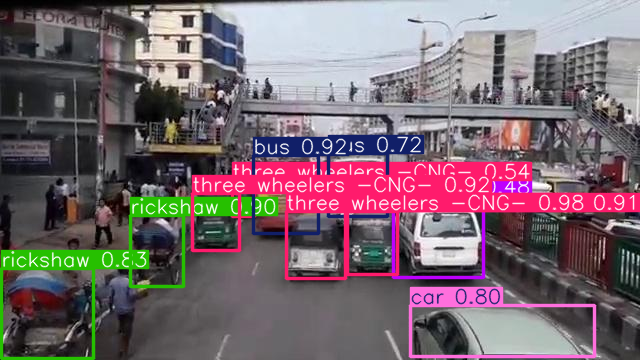

In [14]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train2/weights/best.pt')

test_image_dir = '/content/dataset/trafic_data/valid/images'
random_image = random.choice(os.listdir(test_image_dir))
image_path = os.path.join(test_image_dir, random_image)

results = model.predict(source=image_path, conf=0.3)
res_plotted = results[0].plot()

print(f"Results for: {random_image}")
cv2_imshow(res_plotted)

In [15]:
from ultralytics import YOLO

model = YOLO('/content/runs/detect/train2/weights/best.pt')

metrics = model.val()

print("-" * 30)
print(f"Mean Average Precision (mAP@50): {metrics.box.map50:.3f}")
print(f"Mean Average Precision (mAP@50-95): {metrics.box.map:.3f}")
print(f"Precision (All classes): {metrics.box.mp:.3f}")
print(f"Recall (All classes): {metrics.box.mr:.3f}")
print("-" * 30)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,743 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1658.0±556.8 MB/s, size: 36.9 KB)
val: Scanning /content/dataset/trafic_data/valid/labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 78.6Mit/s 0.0s
val: /content/dataset/trafic_data/valid/images/Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg: 9 duplicate labels removed
val: /content/dataset/trafic_data/valid/images/Pias--360-_PNG.rf.8405b0e44009a9300e0a1100ccf7d5b3.jpg: 7 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.7it/s 4.1s
                   all        300       2568      0.591      0.395      0.385      0.237
               bicycle         30         32      0.483      0.469      0.489       0.22
                   bus        220        425

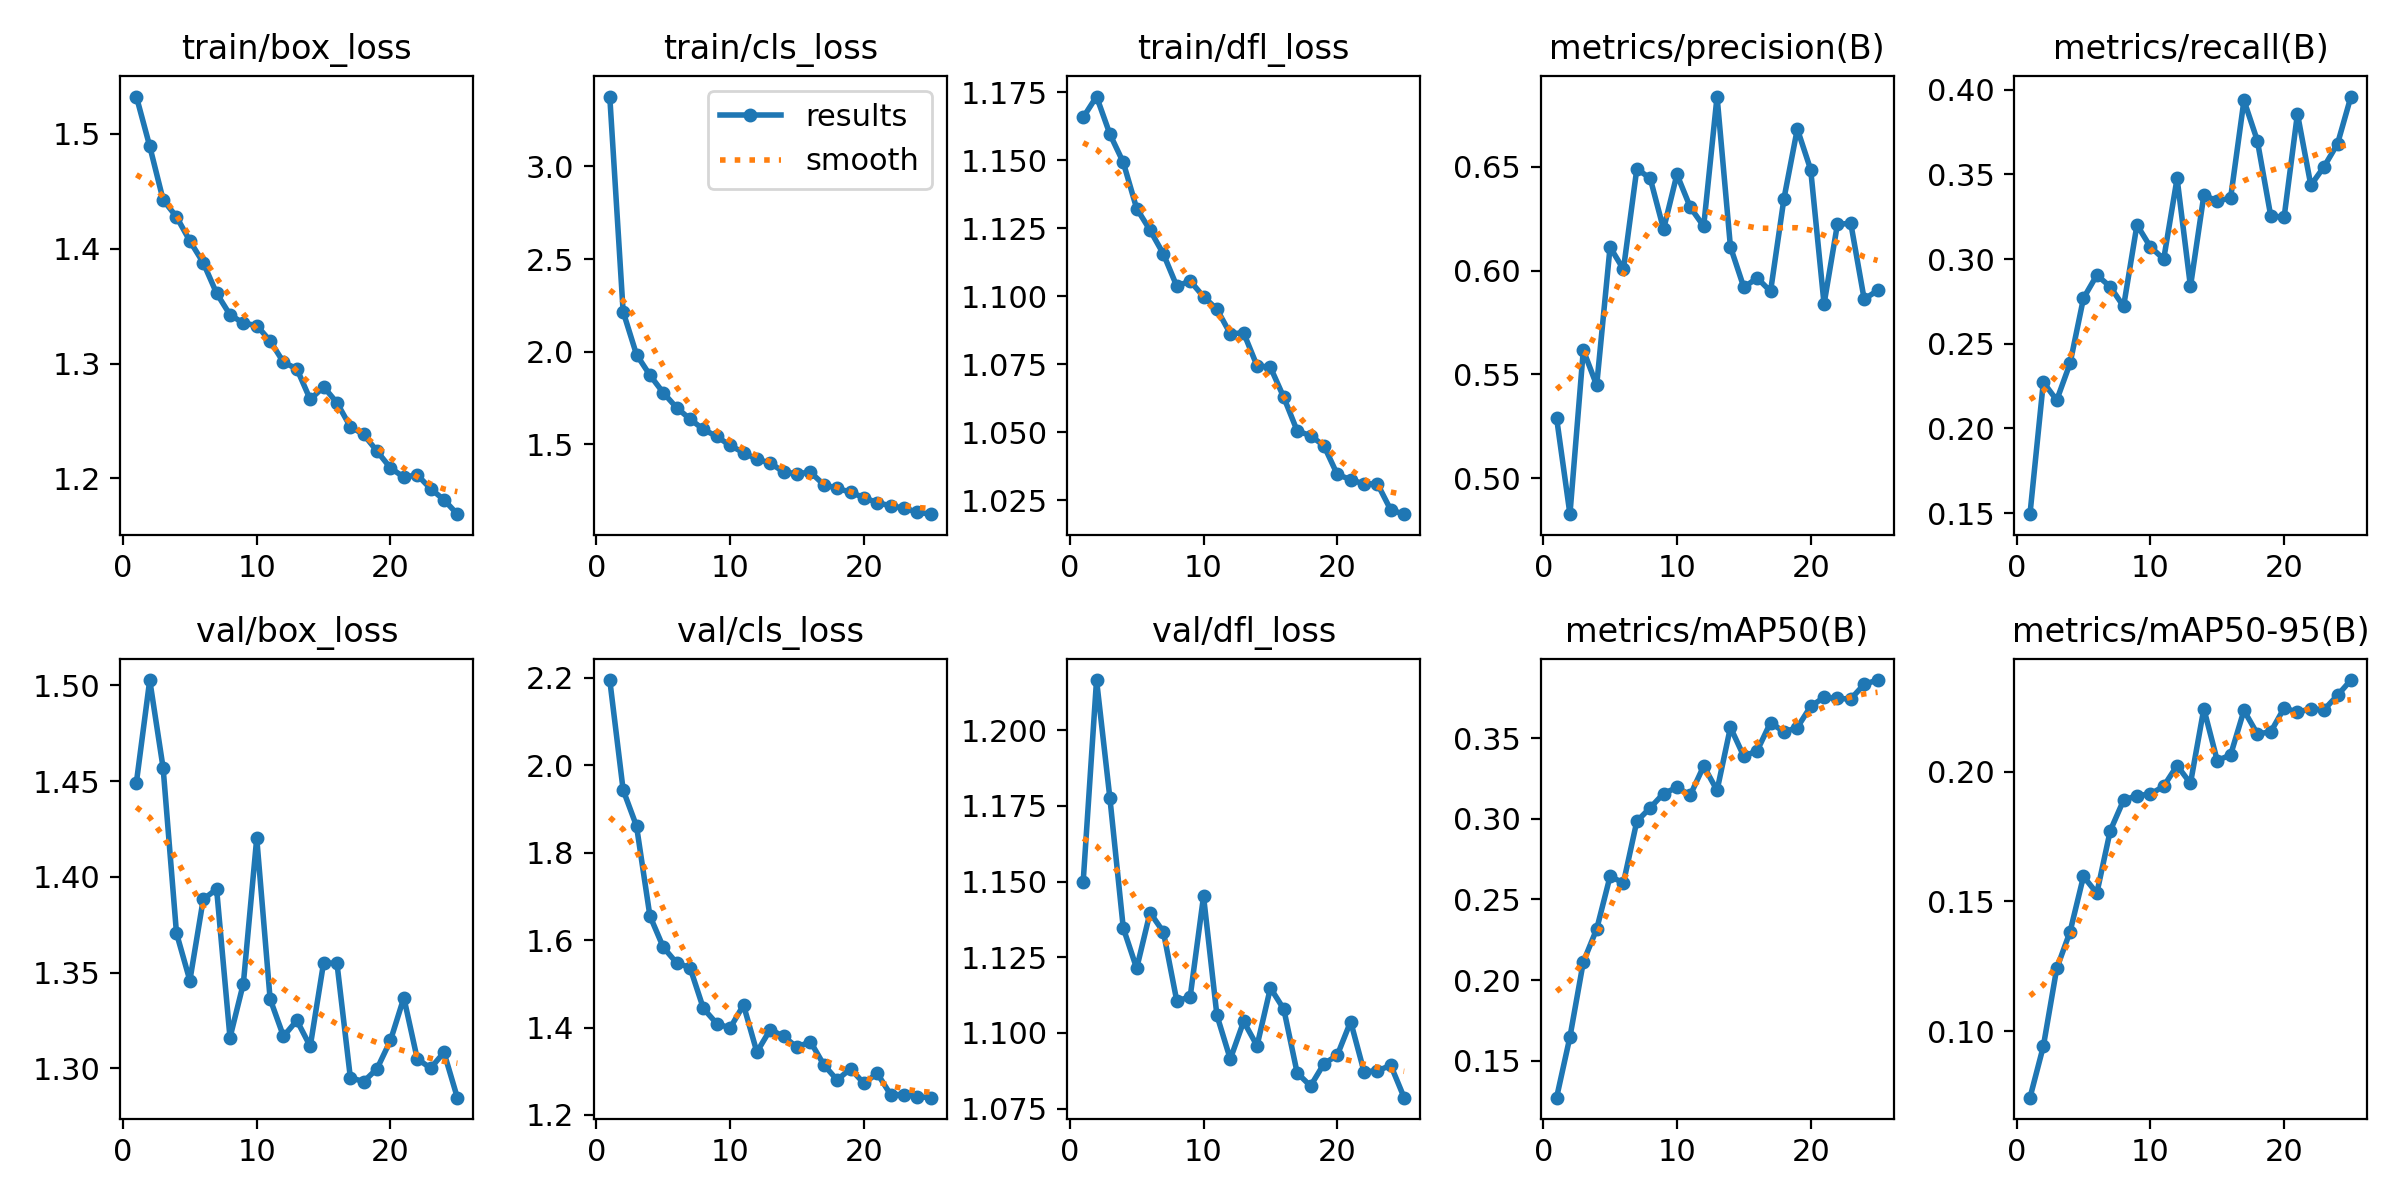

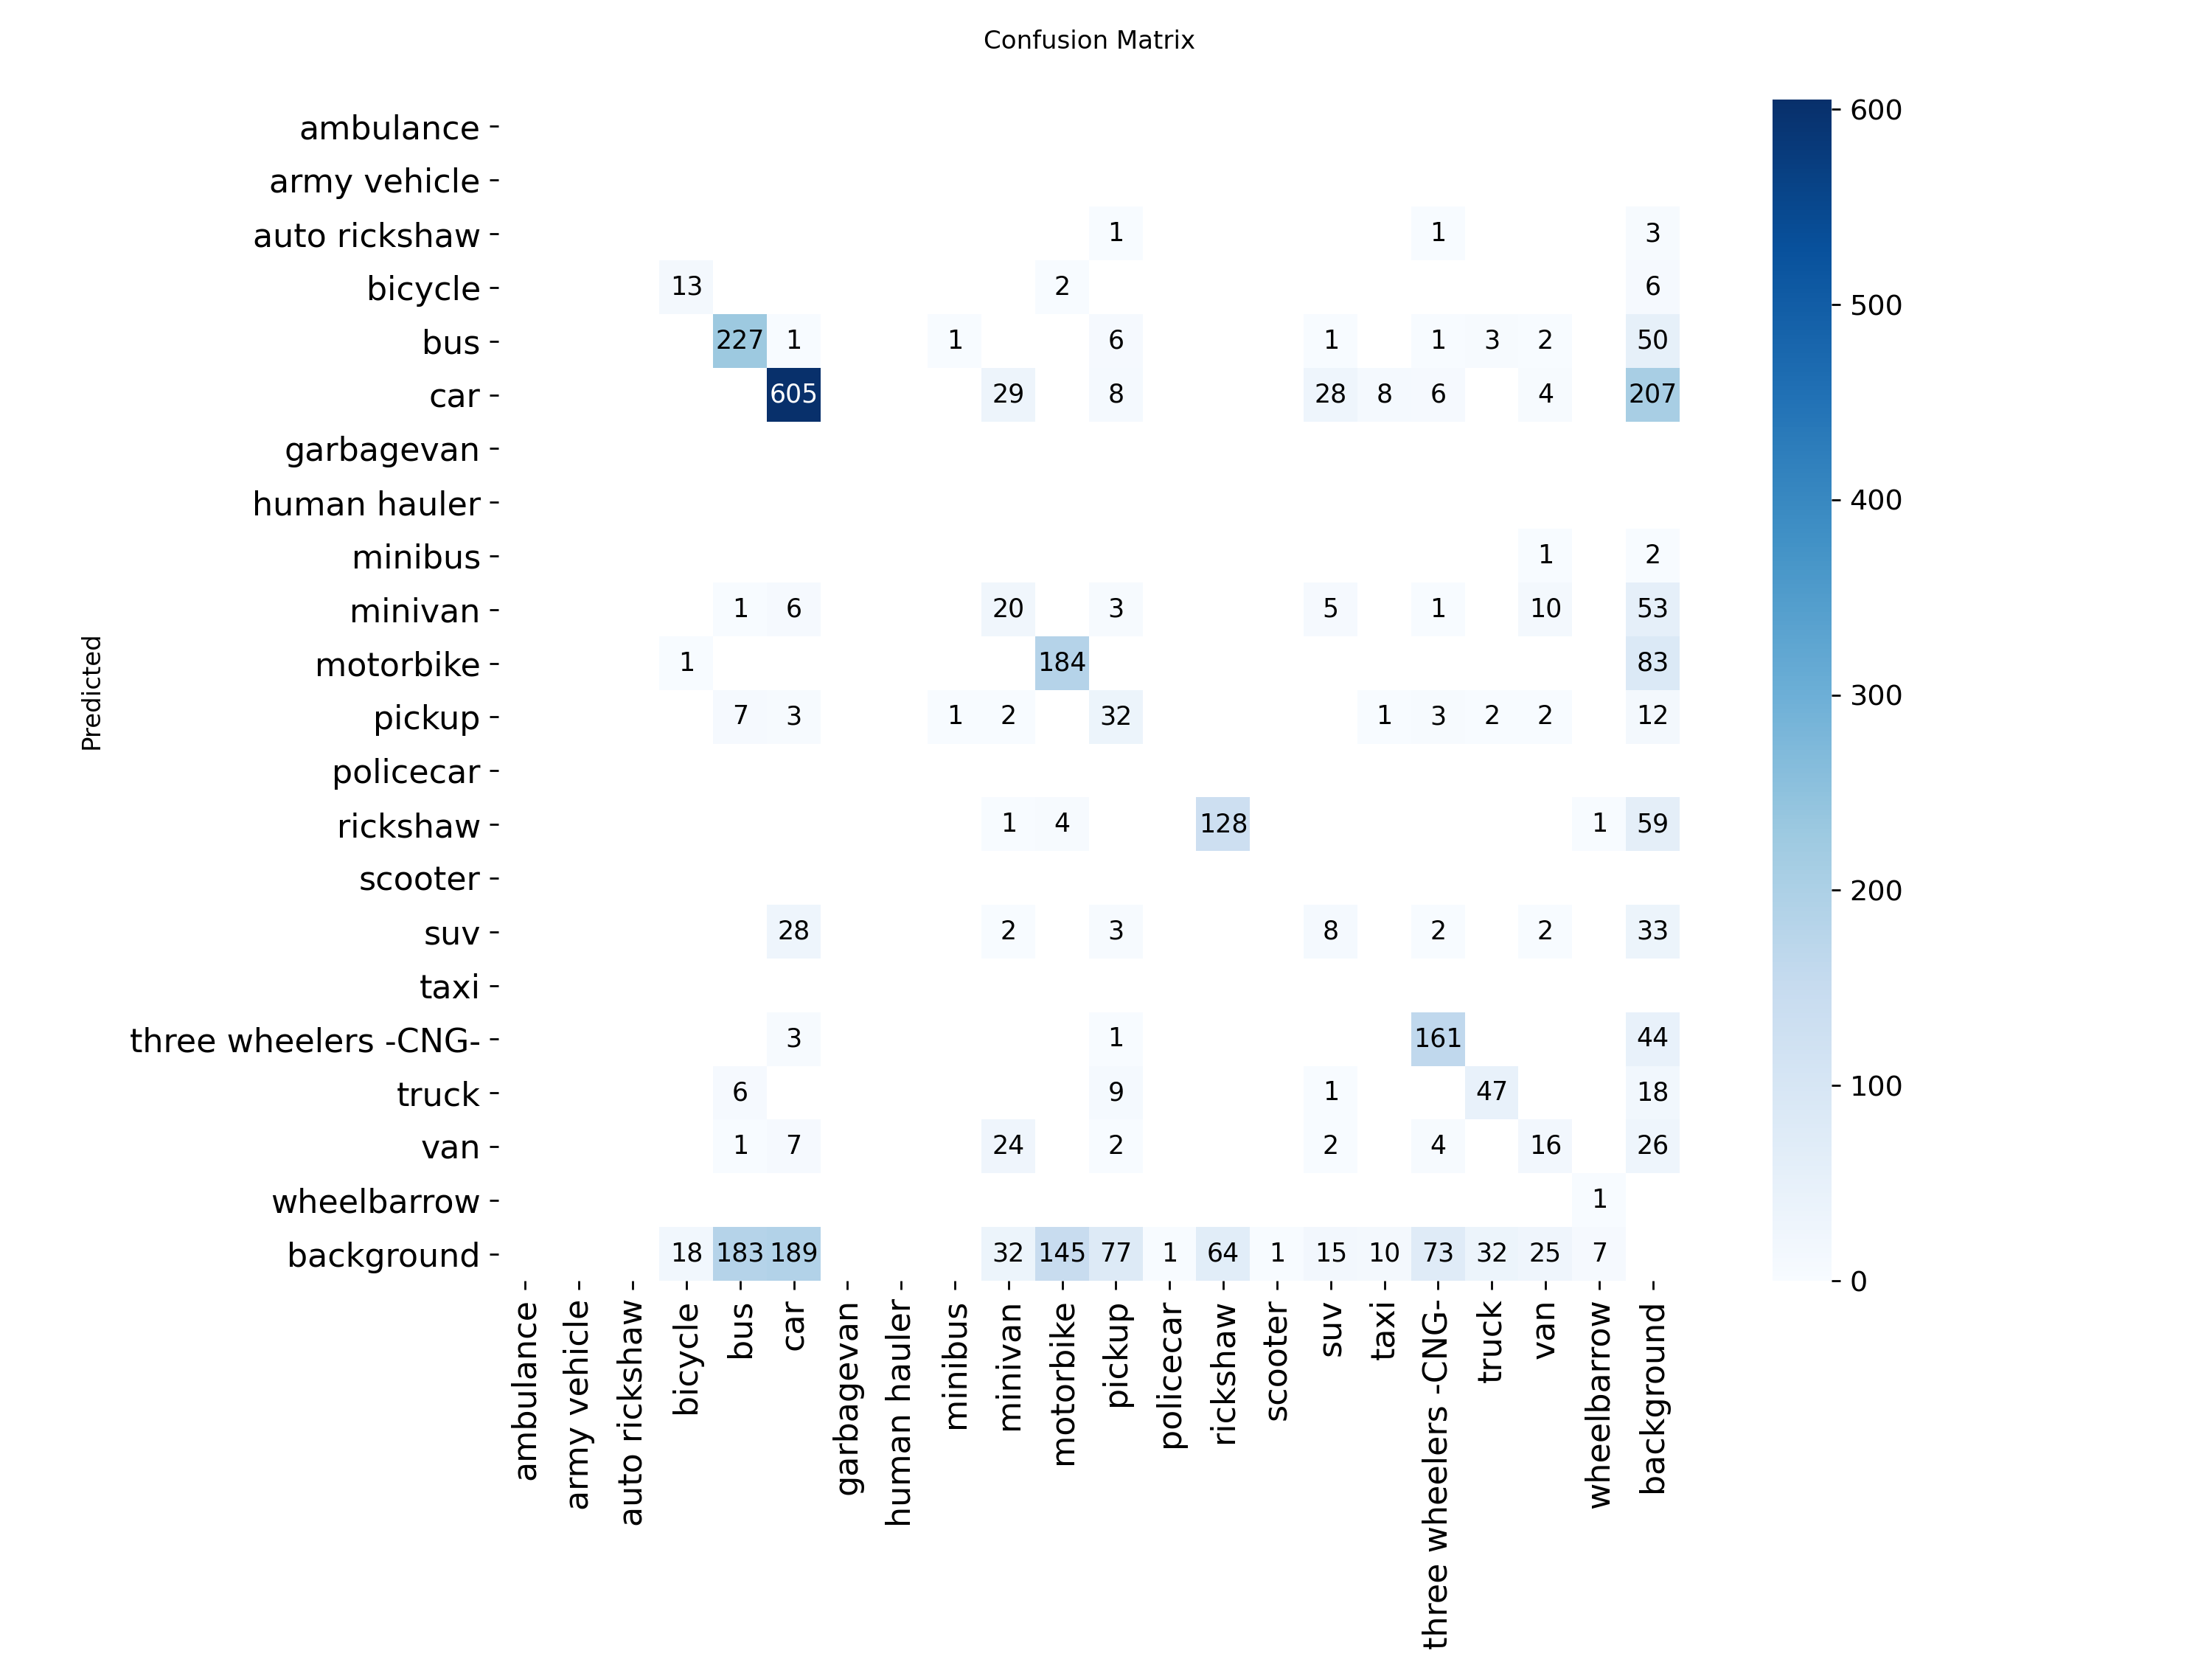

In [16]:
from IPython.display import Image, display


display(Image(filename='/content/runs/detect/train2/results.png', width=800))

display(Image(filename='/content/runs/detect/train2/confusion_matrix.png', width=800))